In [5]:
import gc
import os
import sys
import logging
import warnings
from pathlib import Path
import matplotlib as mpl
import pandas as pd

SRCDIR = Path('../../../')
DATADIR = Path("../../../../data") / "processed" / "spatial" / "Xenium" / "0038438_adipose"

sys.path.insert(0, '../../../')
print(sys.path)
logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

import spatialdata as sd
import spatialdata_plot as sdp

%matplotlib inline
# R_preload()
mpl.rcdefaults()
gc.collect()

['../../../', '../../../', '/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python312.zip', '/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12', '/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/lib-dynload', '', '/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages']


963

# Load data object

In [ ]:
sdata = sd.read_zarr(DATADIR / "0038439.zarr")
sdata

In [ ]:
sdata.pl.render_images(
    "morphology_focus",
    cmap="viridis",
    channel=["ATP1A1/CD45/E-Cadherin"],
    norm=mpl.colors.LogNorm(),
    # ).pl.render_shapes(
    #     "cell_boundaries",
    #     fill_alpha=0.5,
    #     na_color="blue",
    #     outline_width=0.3,
    #     outline_color="white",
).pl.show(coordinate_systems="global", title="IF image")

# Filter on adipose tissue

In [ ]:
sdata_crop = sd.bounding_box_query(
    sdata,
    min_coordinate=[7000, 0],
    max_coordinate=[27000, 18000],
    axes=("x", "y"),
    target_coordinate_system="global",
)

sdata_crop.pl.render_images(
    "morphology_focus",
    cmap="viridis",
    channel=["ATP1A1/CD45/E-Cadherin"],
    norm=mpl.colors.LogNorm(),
).pl.render_shapes(
    "cell_circles",
    fill_alpha=0.8,
    na_color="red",
    outline_width=0.01,
    outline_color="black",
).pl.show(
    coordinate_systems="global", title="Cell segmentation"
)

sdata_crop

In [ ]:
# filter based on circles
adipose_cell_ids = pd.read_csv(
    DATADIR / "xenium-038439-adipose_tissue.csv", skiprows=966
)["Cell ID"]
sdata_crop.tables["table"] = sdata_crop["table"][
    sdata_crop["table"].obs["cell_id"].isin(adipose_cell_ids)
]

# filter minimum 10 UMIs each
mask = sdata_crop.tables["table"].obs["transcript_counts"] >= 10
sdata_crop.tables["table"] = sdata_crop.tables["table"][mask]

sdata_crop.shapes, sdata_crop.tables["table"] = sd.match_element_to_table(
    sdata_crop, list(sdata_crop.shapes.keys()), "table"
)

sdata_crop.pl.render_shapes(
    "cell_circles",
    color="transcript_counts",
    # fill_alpha=0.8,
    # na_color="red",
    # outline_width=0.01,
    # outline_color="black",
).pl.show(coordinate_systems="global", title="Cell segmentation")

# Process transcriptomic data

In [20]:
CLUSTER_KEY = "leiden"
DE_KEY = "DEG"
resolutions = [0.5, 0.8]

### Single cell analysis

In [ ]:
adata = sdata_crop.tables["table"]
adata.layers["counts"] = adata.X.copy()
adata = Filter_QC(adata, 10, 0, 0)
check_QCPlot(adata.obs, "log1p_n_genes_by_counts", "segmentation_method")

In [ ]:
Normalize(adata)
PCA(adata, gene_mask=None, key="PCA", comp=20)
Visualize(adata, basis_key="PCA")
Cluster(adata, resolutions=resolutions)

In [ ]:
for embedding in [f"UMAP", f"LocalMAP"]:
    r, c = 1, len(resolutions)
    axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")[1].flatten()

    for i, res in enumerate(tqdm(resolutions)):
        res_key = f"{CLUSTER_KEY}_{res:.1f}"
        cluster_c = color_gen(adata.obs[res_key].cat.categories)
        adata.obs[res_key] = adata.obs[res_key].astype(int).astype("category")

        sc.pl.embedding(
            adata,
            basis=embedding,
            color=res_key,
            ax=axs[i],
            show=False,
            legend_loc="on data",
            legend_fontoutline=2,
            legend_fontsize=15,
            palette=cluster_c,
        )
        axs[i].annotate(
            f"n = {adata.shape[0]}",
            size=15,
            fontweight="bold",
            xy=(0.98, 0.02),
            xycoords="axes fraction",
            horizontalalignment="right",
            verticalalignment="bottom",
        )

In [ ]:
# original subclusters
RUN_DEG = True

# change to string for DEGs
for col in adata.obs.columns:
    if "leiden" in col:
        adata.obs[col] = adata.obs[col].astype(str).astype("category")

for res in resolutions:
    res_key = f"{CLUSTER_KEY}_{res:.1f}"
    de_key = f"{DE_KEY}_{res:.1f}"
    n_clust = len(adata.obs[res_key].unique())

    # calculate DEGs
    if RUN_DEG is True:
        clear_uns(adata, res_key)
        sc.tl.rank_genes_groups(
            adata,
            groupby=res_key,
            key_added=de_key,
            use_raw=False,
            layer="normalized",
            # method="wilcoxon",
        )

    # plot DEGs
    N_genes = 20
    top_genes = {}
    for group, df in sc.get.rank_genes_groups_df(adata, group=None, key=de_key).groupby(
        "group"
    ):
        top_genes[group] = df["names"][:N_genes].tolist()

    f, ax = plt.subplots(1, 1, figsize=(n_clust * 5, 5), layout="constrained")
    sc.pl.rank_genes_groups_dotplot(
        adata,
        groupby=res_key,
        key=de_key,
        # n_genes=20,
        var_names=top_genes,
        # standard_scale="var",
        values_to_plot="logfoldchanges",
        cmap="bwr",
        colorbar_title="log fold change",
        ax=ax,
        title=f"{res_key}_DEGs",
        vmin=-4,
        vmax=4,
    )

    sc.pl.rank_genes_groups_heatmap(
        adata,
        key=de_key,
        groupby=res_key,
        layer="normalized",
        n_genes=30,
    )

In [ ]:
for col in ["leiden_0.5", "leiden_0.8"]:
    adata.obs[["cell_id", col]].rename(columns={col: "group"}).to_csv(
        DATADIR / f"0038439_{col}.csv"
    )

### Integrate back into spatialdata object

In [ ]:
clear_adata(adata, ["dendrogram", "colors", "X_pca"])
sd.sanitize_table(adata)
sdata_crop.shapes, sdata_crop.tables["table"] = sd.match_element_to_table(
    sdata_crop, list(sdata_crop.shapes.keys()), "table"
)

sdata_crop.pl.render_images(
    "morphology_focus",
    cmap="gray_r",
    # channel=['ATP1A1/CD45/E-Cadherin'],
    norm=mpl.colors.LogNorm(),
).pl.render_shapes(
    "cell_circles",
    color="leiden_0.5",
    # fill_alpha=0.3,
    # na_color="red",
    outline_width=0.01,
    outline_color="black",
).pl.show(
    coordinate_systems="global", title="Clusters"
)

In [ ]:
# switch table annotation
adata.obs["region"] = "cell_boundaries"
adata.obs["region"] = adata.obs["region"].astype("category")
adata.uns["spatialdata_attrs"]["region"] = "cell_boundaries"

In [ ]:
t1_adata = sd.bounding_box_query(
    sdata_crop,
    min_coordinate=[7500, 0],
    max_coordinate=[13000, 6000],
    axes=("x", "y"),
    target_coordinate_system="global",
)

axs = plt.subplots(1, 2, figsize=(20, 10))[1]

for i, col in enumerate(["leiden_0.5", "leiden_0.8"]):
    t1_adata.pl.render_images(
        "morphology_focus",
        cmap="gray_r",
        # channel=['ATP1A1/CD45/E-Cadherin'],
        norm=mpl.colors.LogNorm(),
    ).pl.render_shapes(
        "cell_boundaries",
        color=col,
        fill_alpha=1,
        # na_color="red",
        outline_width=0.01,
        outline_color="black",
    ).pl.show(
        ax=axs[i], coordinate_systems="global", title="Clusters"
    )

# SAVE / LOAD

In [ ]:
sdata_crop.write(DATADIR / "0038439_adipose_CLEANED.zarr", overwrite=True)

In [6]:
sdata_crop = sd.read_zarr(DATADIR / "0038439_adipose_CLEANED.zarr")
sdata_crop

SpatialData object, with associated Zarr store: /mnt/DATA/home/ethung/projects/spatial_seq/data/processed/spatial/Xenium/0038438_adipose/0038439_adipose_CLEANED.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 18000, 20000), (4, 9000, 10000), (4, 4500, 5000), (4, 2250, 2500), (4, 1125, 1250)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (18000, 20000), (9000, 10000), (4500, 5000), (2250, 2500), (1125, 1250)
│     └── 'nucleus_labels': DataTree[yx] (18000, 20000), (9000, 10000), (4500, 5000), (2250, 2500), (1125, 1250)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (587, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (399, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (430, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (399, 480)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels

# Sandbox

In [ ]:
t1_adata = sd.bounding_box_query(
    sdata_crop,
    min_coordinate=[9000, 0],
    max_coordinate=[13000, 6000],
    axes=("x", "y"),
    target_coordinate_system="global",
)

t2_adata = sd.bounding_box_query(
    sdata_crop,
    min_coordinate=[21000, 11500],
    max_coordinate=[24500, 15000],
    axes=("x", "y"),
    target_coordinate_system="global",
)

sd.sanitize_table(sdata_crop['table'])

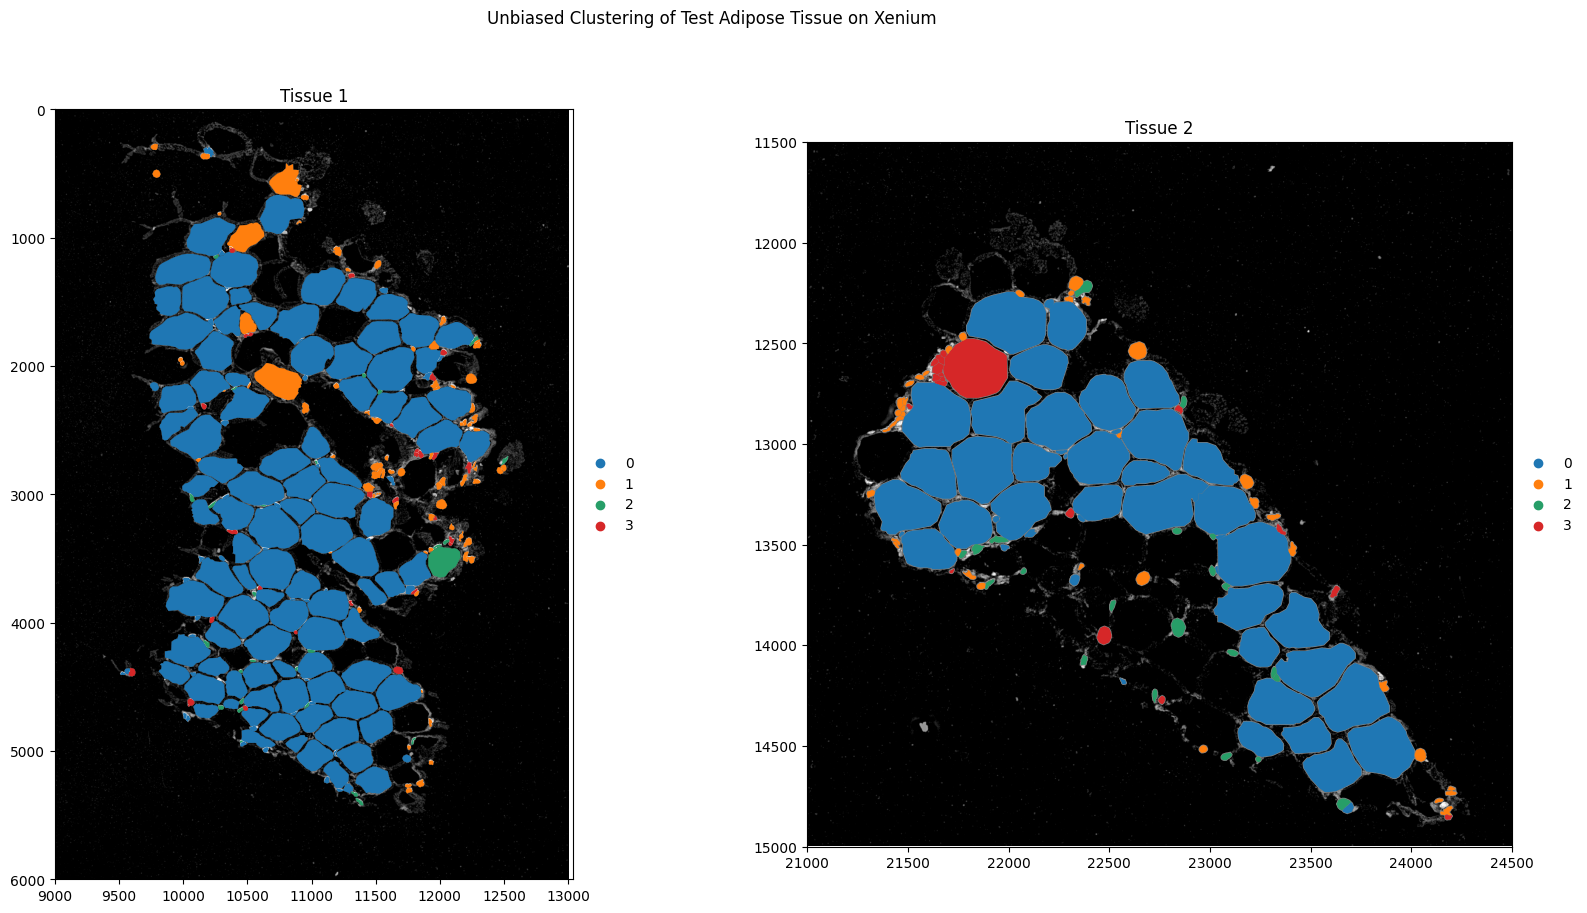

In [29]:
for i, col in enumerate(["leiden_0.5"]):
    axs = plt.subplots(1, 2, figsize=(20, 10))[1]
    t1_adata.pl.render_images(
        "morphology_focus",
        cmap="gray_r",
        # channel=['ATP1A1/CD45/E-Cadherin'],
        norm=mpl.colors.LogNorm(),
    ).pl.render_shapes(
        "cell_boundaries",
        color=col,
        fill_alpha=1,
        # na_color="red",
        outline_width=0.1,
        outline_color="white",
    ).pl.show(
        ax=axs[0], coordinate_systems="global", title="Tissue 1"
    )
    t2_adata.pl.render_images(
        "morphology_focus",
        cmap="gray_r",
        # channel=['ATP1A1/CD45/E-Cadherin'],
        norm=mpl.colors.LogNorm(),
    ).pl.render_shapes(
        "cell_boundaries",
        color=col,
        fill_alpha=1,
        # na_color="red",
        outline_width=1,
        outline_color="grey",
    ).pl.show(
        ax=axs[1], coordinate_systems="global", title="Tissue 2"
    )
    plt.suptitle("Unbiased Clustering of Test Adipose Tissue on Xenium")

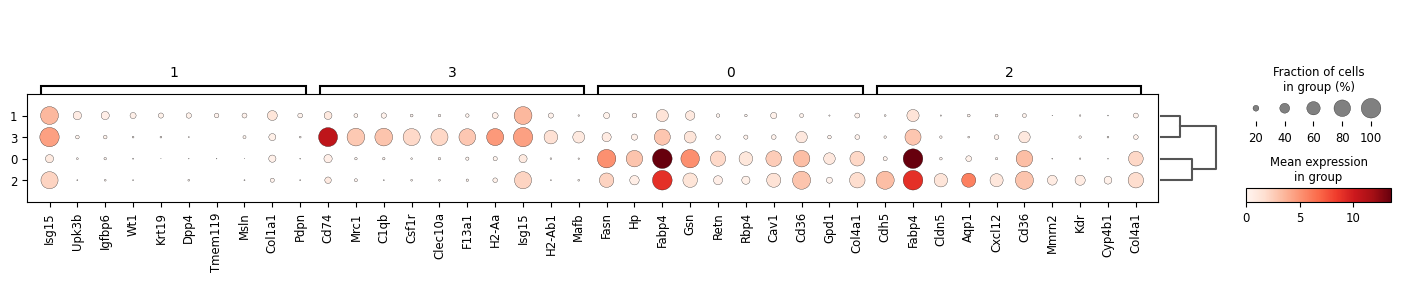

In [10]:
sc.pl.rank_genes_groups_dotplot(sdata_crop['table'], key="DEG_0.5")